In this notebook, we will implement a neural network from scratch using numpy and maths. This will greatly help in understanding the workings of a neural network in the most bare and crucial fashion. 

The Dataset that we are going to be using is the MNIST dataset of handwritten digits. The files are going to be "train.csv" and "test.csv". 

First, Importing the important libraries for the notebook. We will be using  
- Numpy - For maths implementation.
- pandas - for reading the dataset.
- matplotlib - for graphing images and other values. 

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

After this, we will add our dataset for training. 

In [78]:
df = pd.read_csv("train.csv")

In [79]:
df.shape

(42000, 785)

In [80]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We can also visualize the actual images instead of just pixel values using matplotlib.

In [81]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
19206,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


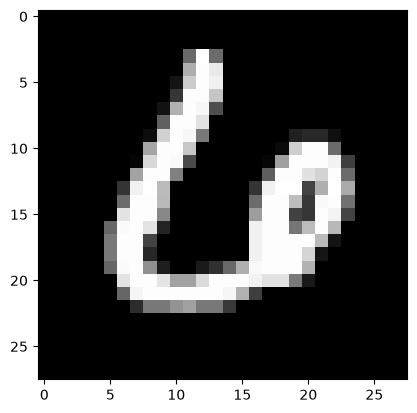

In [82]:
plt.imshow(df.iloc[1805, 1:].to_numpy().reshape(28, 28))

We want the dataset in form of a numpy array rather than a DataFrame.

In [83]:
data = np.array(df)
m,n = data.shape
# We are going to shuffle the data.
np.random.shuffle(data)

To avoid the risk of overfitting, we will be splitting the data into a dev data and a training data. We can train the model on training data and then perform cross validation on the dev data to test the hyperparameters to see the results, reducing the risk of overfitting on actual training data.

We will be transposing the arrays so that instead of rows as features, we would have columns are features. This would make things easier later on.

In [84]:
#Dev data
data_dev = data[0:1000].T #transposing the matrix.
Y_dev = data_dev[0] # This is the actual label.
X_dev = data_dev[1:n]  # These are the features of the label.

#Actual training data
data_train = data[1000:m].T #transposing the matrix
Y_train = data_train[0] # Actual labels
X_train = data_train[1:n]/ 255.0 # Features of labels

In [85]:
def innit_params():
    W1 = (np.random.rand(10,784) - 0.5) *0.01
    b1 = (np.random.rand(10,1) - 0.5) *0.01

    W2 = np.random.rand(10,10) - 0.5
    b2 = np.random.rand(10,1) - 0.5

    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0,Z)

def SoftMax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)

    Z2 = W2.dot(A1) + b2
    A2 = SoftMax(Z2)

    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() +1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def derivative_ReLU(Z):
    return Z > 0

def backward_prop(Z1, A1, Z2, A2, W2, X, Y):
    one_hot_Y = one_hot(Y)
    m = Y.size

    dZ2 = A2 - one_hot_Y
    dW2 = (dZ2.dot(A1.T)) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m
    dZ1 = W2.T.dot(dZ2) * derivative_ReLU(Z1)

    dW1 = (dZ1.dot(X.T)) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2

def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    return W1, b1, W2, b2

In [86]:
def get_predictions(A):
    return np.argmax(A, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, lr):
    W1, b1, W2, b2 = innit_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)

        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W2, X, Y)

        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

        if i % 50 == 0:
            print("Iterations: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2

In [87]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 10000, 0.1)

Iterations:  0
[8 8 8 ... 8 8 8] [3 4 4 ... 6 3 5]
Accuracy:  0.07982926829268293
Iterations:  50
[3 4 4 ... 6 3 3] [3 4 4 ... 6 3 5]
Accuracy:  0.7041219512195122
Iterations:  100
[3 4 4 ... 6 3 3] [3 4 4 ... 6 3 5]
Accuracy:  0.7955365853658537
Iterations:  150
[3 4 4 ... 6 3 3] [3 4 4 ... 6 3 5]
Accuracy:  0.8313658536585365
Iterations:  200
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.853780487804878
Iterations:  250
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.8677073170731707
Iterations:  300
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.8764146341463415
Iterations:  350
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.885
Iterations:  400
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.8903170731707317
Iterations:  450
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.8939268292682927
Iterations:  500
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.8979512195121951
Iterations:  550
[3 4 4 ... 6 3 5] [3 4 4 ... 6 3 5]
Accuracy:  0.9011707317073171
Iterations:  600
[3 

In [88]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation = 'nearest' )
    plt.show()

Prediction:  [4]
Label:  4


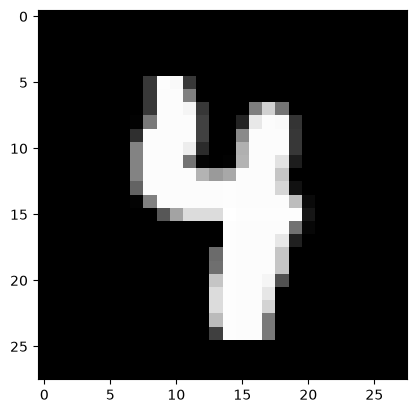

In [89]:
test_prediction(1805, W1, b1, W2, b2)

In [90]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[6 5 4 9 8 8 6 8 6 2 3 8 5 5 8 0 9 6 6 6 6 4 0 6 5 1 7 1 7 7 9 8 7 0 8 3 6
 7 0 4 6 2 5 0 4 9 7 1 3 4 8 6 8 6 3 2 8 3 1 0 1 3 6 7 7 4 6 8 3 3 9 8 5 6
 6 4 5 3 2 2 7 1 3 5 3 8 8 5 5 3 7 2 4 1 7 0 8 5 0 3 1 7 7 4 8 1 3 1 7 0 4
 3 3 1 7 4 1 8 2 7 6 0 9 2 2 3 1 8 8 5 1 8 5 8 9 6 3 2 0 9 6 2 4 1 6 8 6 3
 4 8 8 2 0 5 3 1 2 6 6 9 8 2 8 8 0 3 2 4 2 8 2 9 7 9 5 5 2 5 7 4 4 4 6 3 4
 1 3 2 9 6 3 1 2 0 6 0 8 8 1 6 5 1 9 5 3 7 3 3 3 7 5 0 3 3 7 8 4 9 4 4 2 0
 4 1 7 6 3 5 8 8 6 8 5 9 6 4 8 9 2 3 8 2 7 1 8 3 0 1 9 6 0 9 0 3 0 2 2 1 3
 6 3 2 9 9 2 0 1 6 7 9 7 5 4 4 3 7 3 3 8 7 5 7 6 9 7 4 0 5 2 1 7 3 3 2 6 2
 3 1 5 2 8 2 0 6 9 1 4 2 4 7 6 0 4 2 0 1 5 5 9 3 8 2 3 1 8 3 9 4 8 0 3 8 8
 3 2 6 0 7 0 9 8 5 9 3 7 8 0 3 2 6 5 8 7 3 8 1 7 0 6 7 0 8 2 9 1 8 8 3 5 5
 4 8 9 4 4 6 8 5 3 9 2 7 0 9 0 9 1 8 1 6 0 1 5 3 5 7 0 1 6 8 3 4 0 2 2 2 7
 1 3 6 6 8 6 1 9 8 5 7 3 0 7 4 6 9 7 6 4 3 0 0 8 3 1 1 9 9 8 6 8 2 8 2 0 8
 6 8 0 0 2 0 6 0 2 7 5 7 0 2 1 5 3 8 7 8 8 5 4 5 6 9 4 4 9 1 3 9 4 8 0 4 2
 7 3 7 8 7 4 1 7 5 8 9 9 

np.float64(0.901)